# Deconvolved Spatial Transcriptomics Data Analysis

In [1]:
# Import 
library(Seurat)
library(grid)
library(ggplot2)
library(viridis)
library(dplyr)
library(patchwork)
set.seed(1)

# Multicore CPU usage activation - Future

library(future)

# plan("multicore", workers = 24) # Mac Pro 6.1
# plan(workers = 36) # iMac Pro 1.1
# plan("multicore", workers = 8) # 4 core Intel CPU and M1 have 8 threads
# plan("multicore", workers = 12) # 6 core Intel CPU has 12 threads
plan("multicore", workers = 10) # 10 core M1 Pro CPU has 10 threads

# Set RAM Size to 3/4 of total RAM

# options(future.globals.maxSize = 48000 * 1024^2) # Mac Pros have 64 Gb
options(future.globals.maxSize = 16000 * 1024^2) # iMacs and MacBook Pros have 16 Gb

future.seed=TRUE # Removes future-generated statistical errors

data_dir <- "./Synthetic Visium/deconvolved"

print("Loading 10X Spatial data...")
seurat_obj <- Load10X_Spatial(
  data.dir = data_dir,
)

seurat_obj@project.name <- "Breast Cancer"

seurat_obj

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: viridisLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "Loading 10X Spatial data..."


An object of class Seurat 
26157 features across 12382 samples within 1 assay 
Active assay: Spatial (26157 features, 0 variable features)
 1 layer present: counts
 1 spatial field of view present: slice1

[1] "Running QC..."


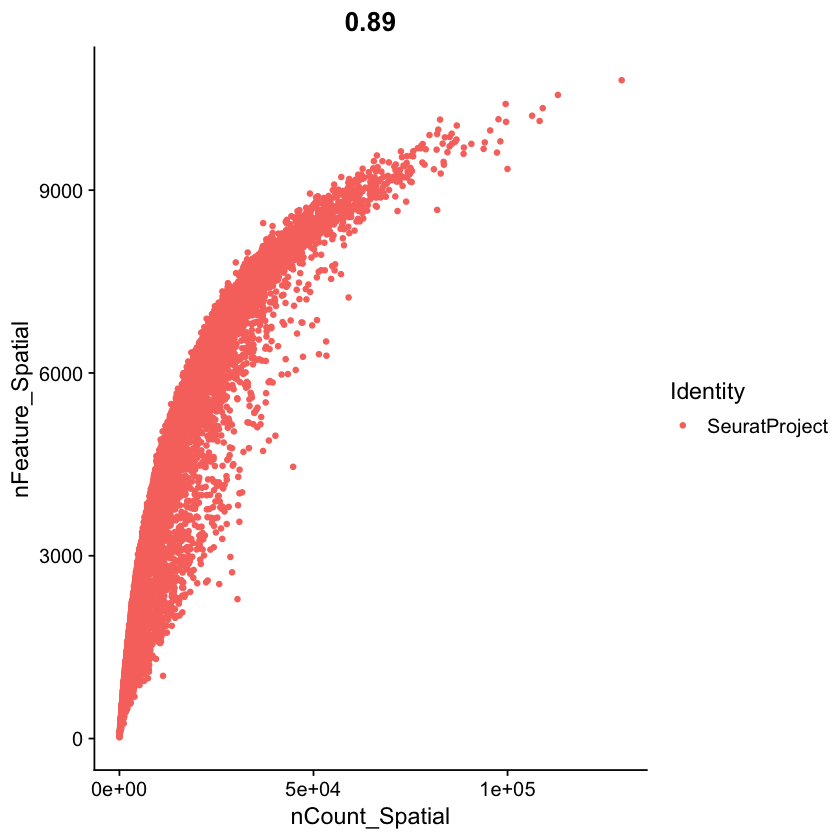

In [2]:
# Quality Control 
print("Running QC...")

FeatureScatter(seurat_obj, feature1 = "nCount_Spatial", feature2 = "nFeature_Spatial")

[1] "Normalizing and Scaling..."


Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix



[1] "Running PCA..."


PC_ 1 
Positive:  PCLAF, NUSAP1, CKS1B, UBE2S, CKS2, RAD21, HIST1H4C, MKI67, HMGB2, PHGDH 
	   UBE2T, SMC4, SKA2, TK1, BUB3, CENPF, TYMS, DHTKD1, PRKDC, CDK1 
	   VANGL1, TUBD1, TOP2A, CENPU, DTYMK, TUBA1C, CCNB1, ANLN, DIAPH3, UBE2C 
Negative:  TCF4, IGFBP7, GSTP1, SPARC, SPARCL1, SOCS3, CALD1, SLC2A3, SRGN, HLA-B 
	   CD74, MSN, CAVIN1, IFI16, HLA-A, ANXA1, COL4A2, FN1, S100A10, PTPRM 
	   ENG, FXYD5, RBMS3, NFKBIA, PECAM1, SERPING1, LDB2, S100A4, LHFPL6, CAV1 
PC_ 2 
Positive:  PTPRC, HCST, SAMSN1, RGS1, ITGB2, CCL5, MTUS2, HLA-DQB1, IL2RG, LAPTM5 
	   RAC2, HLA-DQA2, THSD4, ISG20, CTSD, TYROBP, ARHGAP15, CD52, CD7, FYB1 
	   DTNA, HLA-DPA1, FCER1G, CD3D, HLA-DRB5, SLA, HLA-DPB1, LYZ, HLA-DQA1, CD37 
Negative:  IGFBP7, SPARC, SPARCL1, TCF4, CALD1, CAVIN1, COL4A2, HSPG2, RBMS3, LDB2 
	   CAV1, COL4A1, LHFPL6, NUSAP1, DLC1, GNG11, HMGB2, LAMA4, FSTL1, ADGRL4 
	   ENG, EBF1, RAD21, COL6A2, SASH1, RAMP2, PTPRM, CKS1B, PCLAF, FBN1 
PC_ 3 
Positive:  HLA-DPA1, HLA-DRB1, HLA-DRA, LAPTM5, C

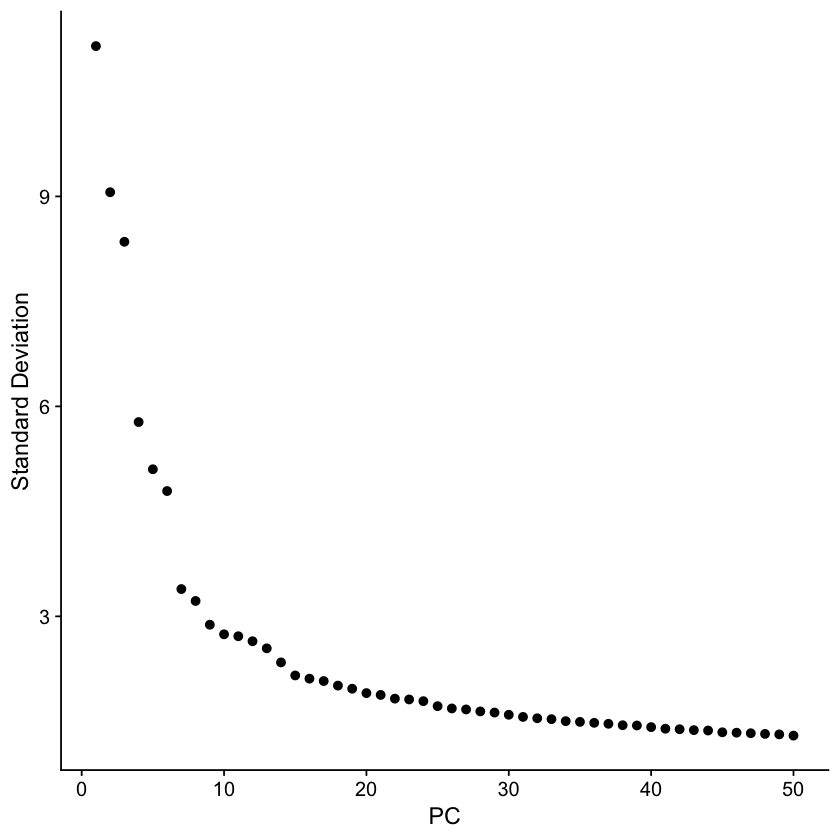

In [3]:
# Normalization & Feature Selection
print("Normalizing and Scaling...")

seurat_obj <- NormalizeData(seurat_obj, normalization.method = "LogNormalize", scale.factor = 10000)
seurat_obj <- FindVariableFeatures(seurat_obj, selection.method = "vst", nfeatures = 2000)
all.genes <- rownames(seurat_obj)
seurat_obj <- ScaleData(seurat_obj, features = all.genes)

# PCA
print("Running PCA...")

seurat_obj <- RunPCA(seurat_obj, features = VariableFeatures(object = seurat_obj))

# Elbow Plot
print(ElbowPlot(seurat_obj, ndims = 50))

In [4]:
# UMAP
dims_use <- 1:29 

print("Running UMAP...")
seurat_obj <- RunUMAP(seurat_obj, dims = dims_use)

[1] "Running UMAP..."


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
17:46:46 UMAP embedding parameters a = 0.9922 b = 1.112

17:46:46 Read 12382 rows and found 29 numeric columns

17:46:46 Using Annoy for neighbor search, n_neighbors = 30

17:46:46 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

17:46:47 Writing NN index file to temp file /var/folders/lk/54m90rgj1fqg895lxsgx1l180000gn/T//RtmpIvQ1za/file44bd63c72beb

17:46:47 Searching Annoy index using 10 threads, search_k = 3000

17:46:47 Annoy recall = 100%

17:46:47 Commencing smooth kNN distance calib

[1] "Clustering..."


Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 12382
Number of edges: 478567

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8872
Number of communities: 16
Elapsed time: 1 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore". [future ‘future_lapply-1’ (820edadc9a70a6a26c4f3eb01b50ad0d-31); on 820edadc9a70a6a26c4f3eb01b50ad0d@MacBook-Pro-Roman.local<17597>]”


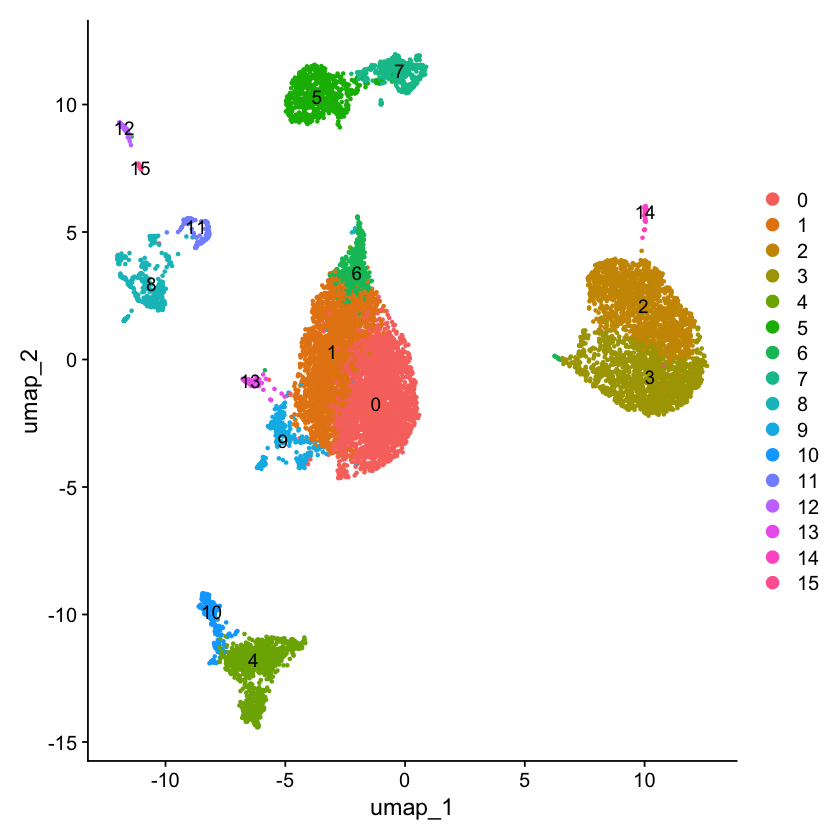

In [5]:
# In Silico Cell Clustering

print("Clustering...")
seurat_obj <- FindNeighbors(seurat_obj, dims = dims_use)
seurat_obj <- FindClusters(seurat_obj, resolution = 0.5) 
DimPlot(seurat_obj, reduction = "umap", label = TRUE, pt.size = 0.5)

In [5]:
all_markers <- FindAllMarkers(
  seurat_obj, 
  only.pos = TRUE,     
  min.pct = 0.25,       
  logfc.threshold = 0.5 
)

library(dplyr)
all_markers_sorted <- all_markers %>%
  group_by(cluster) %>%
  arrange(cluster, desc(avg_log2FC)) 

write.csv(all_markers_sorted, file = "in_silico_all_cluster_markers.csv", row.names = FALSE)

print("Markers saved to 'all_cluster_markers.csv'")

top_markers <- all_markers_sorted %>%
    group_by(cluster) %>%
    slice_head(n = 3)

print(top_markers)

Calculating cluster Tumor

Calculating cluster Dividing Tumor

Calculating cluster Luminal A

Calculating cluster Luminal B

Calculating cluster Ciliated Cells

Calculating cluster Myoepithelial Cells

Calculating cluster Fibroblasts

Calculating cluster Endothelial Cells

Calculating cluster T-cells

Calculating cluster Plasma Cells

Calculating cluster TAMs



[1] "Markers saved to 'all_cluster_markers.csv'"
# A tibble: 33 × 7
# Groups:   cluster [11]
       p_val avg_log2FC pct.1 pct.2 p_val_adj cluster        gene      
       <dbl>      <dbl> <dbl> <dbl>     <dbl> <fct>          <chr>     
 1 0               2.08 0.521 0.19  0         Tumor          NEUROD2   
 2 6.45e-262       2.05 0.386 0.12  1.69e-257 Tumor          SLC44A5   
 3 0               1.93 0.567 0.206 0         Tumor          AP002336.2
 4 0               6.82 0.658 0.014 0         Dividing Tumor AURKB     
 5 0               6.68 0.681 0.017 0         Dividing Tumor CDCA3     
 6 0               6.30 0.495 0.011 0         Dividing Tumor CKAP2L    
 7 0               6.67 0.881 0.151 0         Luminal A      MUCL1     
 8 0               6.32 0.703 0.079 0         Luminal A      CPB1      
 9 0               5.44 0.989 0.594 0         Luminal A      TFF1      
10 0               8.78 0.571 0.016 0         Luminal B      SCGB1D2   
# ℹ 23 more rows


In [15]:
new_cluster_ids <- c(
  # TUMOR 
  "13"  = "Tumor",             
  "6"  = "Tumor",
  "9"  = "Tumor", 
  "0"  = "Tumor", 
  "1"  = "Tumor", 
  "2"  = "Dividing Tumor",   
  "3"  = "Dividing Tumor",   
  "4"  = "Luminal A",        
  "10"  = "Luminal B",        

  # EPITHELIUM
  "14" = "Ciliated Cells",
  "15" = "Myoepithelial Cells",

  # STROMA
  "11"  = "Fibroblasts",      
  "8"  = "Endothelial Cells", 

  # IMMUNE 
  "5"  = "T-cells",          
  "12" = "Plasma Cells",     
  "7"  = "TAMs"              
)

seurat_obj <- RenameIdents(seurat_obj, new_cluster_ids)
seurat_obj$CellType <- Idents(seurat_obj)

In [16]:
# seurat_obj <- readRDS("seurat_codeconv.rds")

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


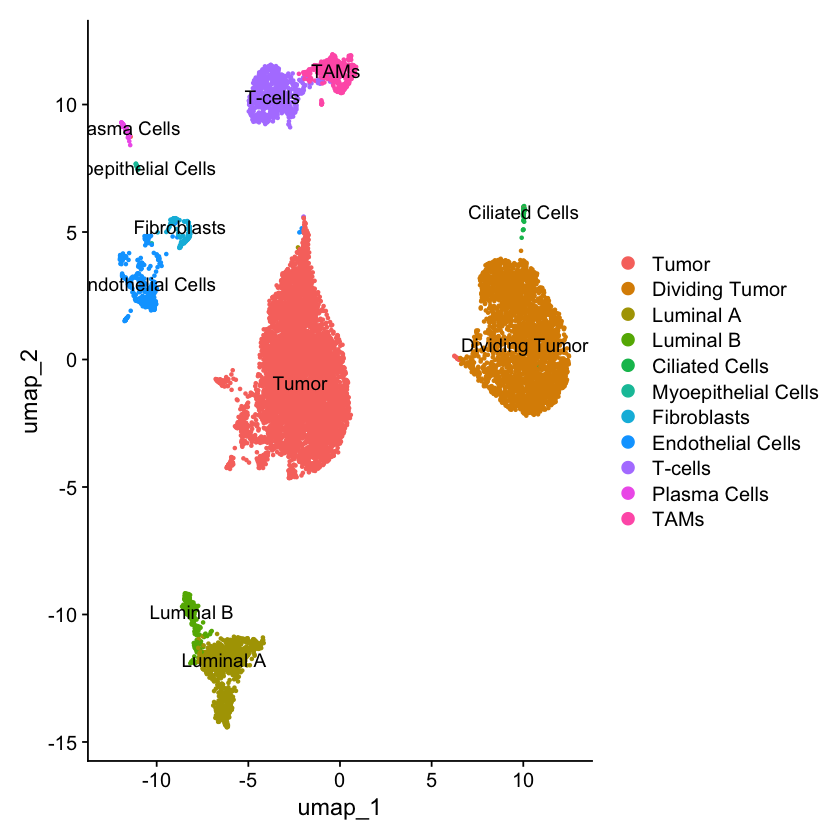

In [58]:
# UMAP Clusters
DimPlot(seurat_obj, reduction = "umap", label = TRUE, pt.size = 0.5) + 
  xlim(-12.5, 12.5)

# Save the plot
ggsave("CoDeconvClusters.jpeg", plot = last_plot(),
       width = 11, height = 10,     
       dpi = 600,                 
       type = "cairo")

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


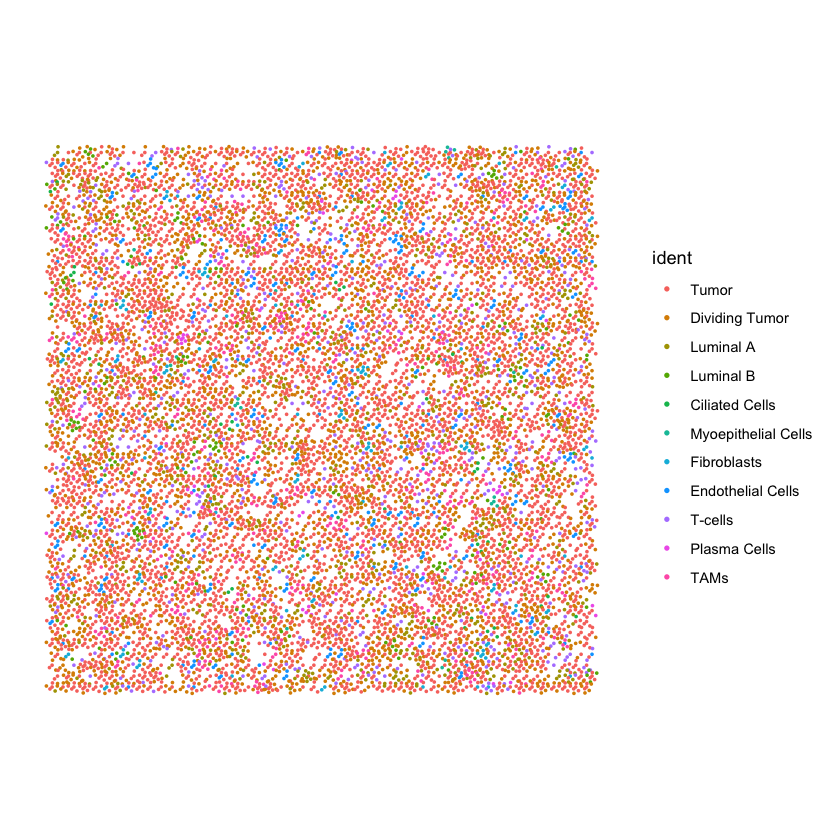

In [18]:
# Spatial Map of the Clusters
SpatialDimPlot(seurat_obj, label = FALSE, label.size = 3, pt.size.factor = 0.25)

ggsave("CoDeconvSpatialClusters.jpeg", plot = last_plot(),
       width = 12, height = 10,     
       dpi = 600,                
       type = "cairo")

Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


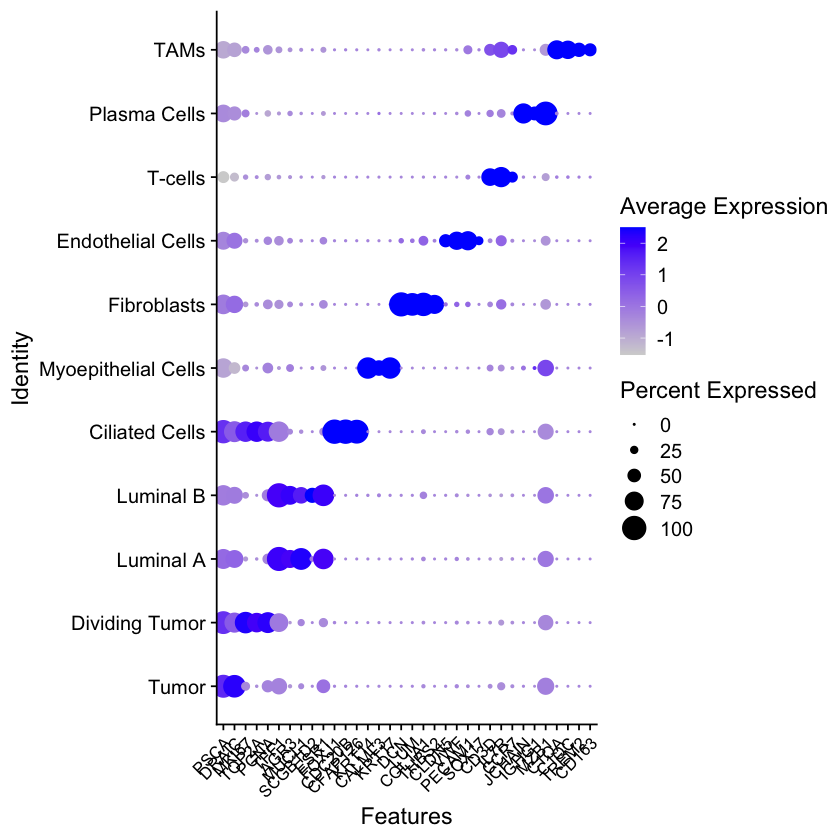

In [3]:
genes_to_plot <- c(
  # TUMOR: 
  "PSCA", "DRAIC",      
  "MKI67", "TOP2A", "PCNA",                      

  # TUMOR: Luminal Lineage
  "TFF1", "AGR3", "MUCL1",             
  "SCGB1D2", "ESR1",             

  # EPITHELIUM           
  "FOXJ1", "CDC20B", "CFAP126",
  "KRT14", "CALML3", "KRT17", 

  # STROMA
  "DCN", "LUM", "COL1A1", "THBS2",      
  "CLDN5", "VWF", "PECAM1", "SOX17",     

  # IMMUNE: T-Cells
  "CD3D", "IL7R", "CCR7",     
  
  # IMMUNE: B-Cells & Plasma
  # "CD19", "MS4A1", "BANK1",             
  "JCHAIN", "IGHG1", "MZB1",            

  # IMMUNE: Myeloid
  "C1QA", "C1QC", "TREM2", "CD163"       
)

genes_to_plot <- unique(genes_to_plot)

# Remove any genes not found
genes_to_plot <- genes_to_plot[genes_to_plot %in% rownames(seurat_obj)]

DotPlot(
  seurat_obj,
  features = genes_to_plot,
) + 
  RotatedAxis() +                
  theme(axis.text.x = element_text(size = 10))

ggsave("CoDeconvDotPlot.jpeg", plot = last_plot(),
       width = 15, height = 5.5,     
       dpi = 600,                
       type = "cairo")

In [4]:
library(dplyr)
library(tidyr)
library(ggplot2)

# 1. Extract spot names and predicted counts from Seurat
md <- seurat_obj@meta.data
md$Spot <- sapply(strsplit(rownames(md), "-Topic-"), "[", 1)

# Aggregate to get cell counts per spot per CellType
pred_counts <- md %>%
  group_by(Spot, CellType) %>%
  summarise(Predicted_Cells = n(), .groups = "drop") %>%
  pivot_wider(names_from = CellType, values_from = Predicted_Cells, values_fill = list(Predicted_Cells = 0))

# 2. Load Ground Truth (FIX: check.names = FALSE preserves spaces and hyphens)
gt_counts <- read.csv("ground_truth_counts.csv", check.names = FALSE)

# Identify the biological cell types from the ground truth columns
# (excluding metadata columns like Spot, Total_Cells, etc.)
gt_celltypes <- setdiff(colnames(gt_counts), c("Spot", "Total_Cells", "X", "Unnamed: 0", "Unnamed..0"))

# 3. Handle missing Cell Types (like B-cells)
for (ct in gt_celltypes) {
  if (!(ct %in% colnames(pred_counts))) {
    pred_counts[[ct]] <- 0
  }
}

# 4. Reshape both into "long" format and merge
gt_long <- gt_counts %>%
  select(Spot, all_of(gt_celltypes)) %>%
  pivot_longer(cols = -Spot, names_to = "CellType", values_to = "True_Cells")

pred_long <- pred_counts %>%
  select(Spot, all_of(gt_celltypes)) %>%
  pivot_longer(cols = -Spot, names_to = "CellType", values_to = "Predicted_Cells")

comp_df <- inner_join(gt_long, pred_long, by = c("Spot", "CellType"))


Global Tissue Composition Pearson r: 0.958
Global Tissue Composition CCC: 0.952


Warning message:
“Using ragg device as default. Ignoring `type` and `antialias` arguments”


[1] "Plot saved as CoDeconv_Global_Composition_Benchmark.jpeg at 600 DPI, width 7.5."


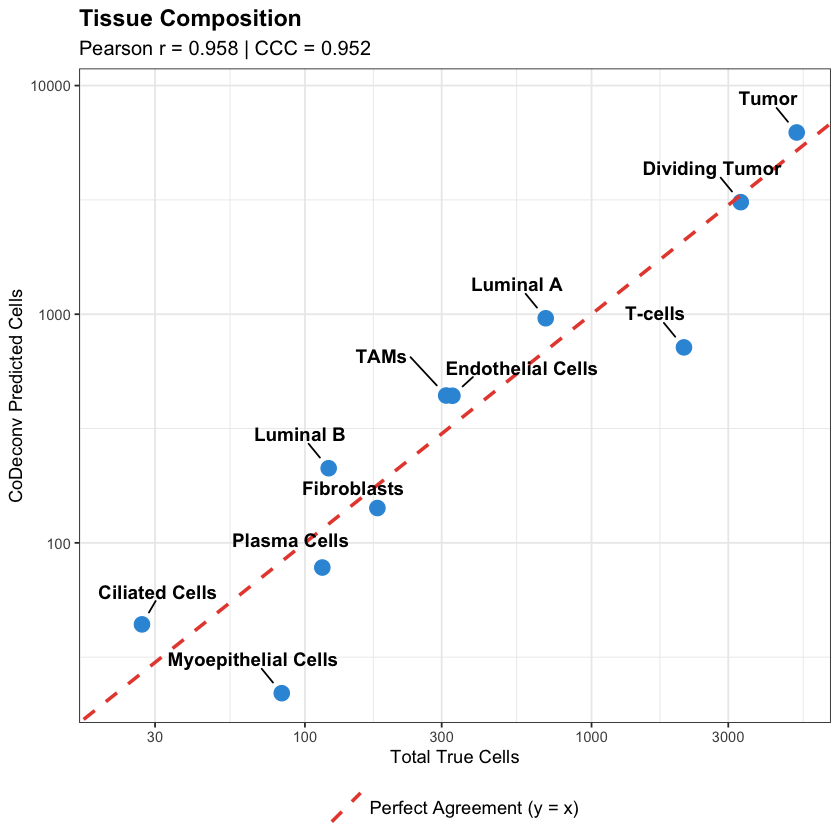

In [7]:
library(dplyr)
library(ggplot2)
library(ggrepel)

# 1. Parameter to drop specific clusters
clusters_to_drop <- c("B-cells")

# 2. Calculate total cells per cell type and filter
bulk_df <- comp_df %>%
  group_by(CellType) %>%
  summarise(
    Total_True = sum(True_Cells),
    Total_Pred = sum(Predicted_Cells),
    .groups = "drop"
  ) %>%
  filter(!(CellType %in% clusters_to_drop))

# 3. Helper function for CCC
calc_ccc <- function(x, y) {
  if (sd(x) == 0 && sd(y) == 0) return(1)
  if (sd(x) == 0 || sd(y) == 0) return(0)
  numerator <- 2 * cor(x, y) * sd(x) * sd(y)
  denominator <- var(x) + var(y) + (mean(x) - mean(y))^2
  return(numerator / denominator)
}

# 4. Calculate Global Pearson Correlation and CCC
global_r <- cor(bulk_df$Total_True, bulk_df$Total_Pred)
global_ccc <- calc_ccc(bulk_df$Total_True, bulk_df$Total_Pred)

cat(sprintf("\nGlobal Tissue Composition Pearson r: %.3f\n", global_r))
cat(sprintf("Global Tissue Composition CCC: %.3f\n", global_ccc))

# 5. Generate Plot
p_bulk <- ggplot(bulk_df, aes(x = Total_True, y = Total_Pred, label = CellType)) +
  # Draw the points
  geom_point(color = "#3498db", size = 4) +
  # Draw the line BEFORE the text (so text renders on top) and force a legend
  geom_abline(aes(slope = 1, intercept = 0, color = "Perfect Agreement (y = x)"), 
              linetype = "dashed", linewidth = 1) +
  scale_color_manual(name = NULL, values = c("Perfect Agreement (y = x)" = "#e74c3c")) +
  # Draw the text labels, nudging them physically UP (y) and LEFT (x) so they float above the line
  geom_text_repel(
    box.padding = 0.8, 
    point.padding = 0.5, 
    size = 4, 
    fontface = "bold", 
    nudge_y = 0.15, 
    nudge_x = -0.1, 
    seed = 42 # Locks the random placement so it looks the same every time
  ) +
  theme_bw() +
  scale_x_log10() + scale_y_log10() + 
  labs(
    title = "Tissue Composition",
    subtitle = sprintf("Pearson r = %.3f | CCC = %.3f", global_r, global_ccc),
    x = "Total True Cells",
    y = "CoDeconv Predicted Cells"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 12),
    legend.position = "bottom", # Move the legend nicely to the bottom
    legend.text = element_text(size = 11)
  )

print(p_bulk)

# 6. Save Plot at 600 DPI
ggsave("CoDeconv_Global_Composition_Benchmark.jpeg", plot = p_bulk,
       width = 7.25, height = 7, dpi = 600, type = "cairo")

print("Plot saved as CoDeconv_Global_Composition_Benchmark.jpeg at 600 DPI, width 7.5.")

In [3]:
# EXPORT CODECONV RESULTS FOR BENCHMARKING

library(dplyr)
library(tidyr)
library(Seurat)

prefix <- "codeconv_synth"

# 1. Re-calculate absolute cell counts directly from Seurat metadata
cat("Extracting absolute counts...\n")
md <- seurat_obj@meta.data
md$Spot <- sapply(strsplit(rownames(md), "-Topic-"), "[", 1)

counts_df <- md %>%
  group_by(Spot, CellType) %>%
  summarise(Predicted_Cells = n(), .groups = "drop") %>%
  pivot_wider(names_from = CellType, values_from = Predicted_Cells, values_fill = list(Predicted_Cells = 0)) %>%
  as.data.frame()

# Format as a clean matrix (Rows = Spots, Cols = CellTypes)
rownames(counts_df) <- counts_df$Spot
counts_df$Spot <- NULL

# Save Counts
write.csv(counts_df, paste0(prefix, "_counts.csv"), row.names = TRUE)

# 2. Calculate and Save Proportions
cat("Calculating proportions...\n")
props_export <- as.data.frame(prop.table(as.matrix(counts_df), margin = 1))
props_export[is.na(props_export)] <- 0 # Catch any empty spots to avoid NaNs

write.csv(props_export, paste0(prefix, "_props.csv"), row.names = TRUE)

# 3. Export Reconstructed Whole Transcriptome (WT GEX)
cat("Aggregating single-cell imputed GEX into spatial spots...\n")
seurat_obj$Spot <- sapply(strsplit(rownames(seurat_obj@meta.data), "-Topic-"), "[", 1)

# Sum expression counts per spot (pseudo-bulking the codeconv cells)
wt_gex_list <- AggregateExpression(seurat_obj, group.by = "Spot", assays = "Spatial")
wt_gex_matrix <- as.matrix(wt_gex_list$Spatial)

# The result is Genes x Spots, but our evaluation script expects Spots x Genes
wt_gex_export <- t(wt_gex_matrix) 

write.csv(wt_gex_export, paste0(prefix, "_wt_gex.csv"), row.names = TRUE)

# 4. Export Per-CellType Reconstructed GEX (UMI sums per CellType, for benchmarking)
cat("Aggregating CoexpressDeconvolve cells into per-CellType pseudobulks...\n")

ct_gex_list <- AggregateExpression(seurat_obj, group.by = "CellType", assays = "Spatial")
ct_gex_matrix <- as.matrix(ct_gex_list$Spatial)   # genes x CellType, UMI sums

write.csv(ct_gex_matrix, paste0(prefix, "_celltype_gex.csv"), row.names = TRUE)
cat(sprintf("Saved per-CellType GEX to %s_celltype_gex.csv\n", prefix))

cat(sprintf("\nSuccessfully exported Counts, Proportions, WT GEX, and per-CellType GEX for %s!\n", prefix))

Extracting absolute counts...
Calculating proportions...
Aggregating single-cell imputed GEX into spatial spots...
Aggregating CoexpressDeconvolve cells into per-CellType pseudobulks...
Saved per-CellType GEX to codeconv_synth_celltype_gex.csv

Successfully exported Counts, Proportions, WT GEX, and per-CellType GEX for codeconv_synth!


In [20]:
saveRDS(seurat_obj, "seurat_codeconv.rds")

# Comparison with the paired scRNA-seq data

In [2]:
seurat_obj <- readRDS('seurat_codeconv.rds')

In [3]:
Seurat <- readRDS('Seurat_Clusters.rds')

In [7]:
head(seurat_obj@meta.data)

,orig.ident,nCount_Spatial,nFeature_Spatial,Spatial_snn_res.0.5,seurat_clusters
,<chr>,<dbl>,<int>,<fct>,<fct>
SYNTH-1-1-1-Topic-4-Cell-1,SeuratProject,3425,1830,4,4
SYNTH-1-1-1-Topic-4-Cell-2,SeuratProject,6144,2735,4,4
SYNTH-1-1-1-Topic-4-Cell-3,SeuratProject,1457,957,4,4
SYNTH-1-2-1-Topic-1-Cell-1,SeuratProject,1544,912,6,6
SYNTH-1-3-1-Topic-1-Cell-1,SeuratProject,8592,3435,1,1
SYNTH-1-3-1-Topic-1-Cell-2,SeuratProject,2854,1634,6,6


In [9]:
library(Seurat)
library(pheatmap)
library(viridis)

CompareSpatialToRef <- function(spatial_obj, ref_obj, 
                                        spatial_col = "CellType", 
                                        ref_col = "CellType",
                                        n_genes = 3500,
                                        file_prefix = "Validation_Result") { 
  
  message(paste0("1. Checking Variable Features (Target: ", n_genes, ")..."))
  
  if (length(VariableFeatures(spatial_obj)) < n_genes) {
    message("   > Recalculating Variable Features...")
    spatial_obj <- FindVariableFeatures(spatial_obj, selection.method = "vst", nfeatures = n_genes)
  }
  top_hvg <- toupper(head(VariableFeatures(spatial_obj), n_genes))
  
  message("2. Aggregating Spatial Data (Visium)...")
  sp_assay <- DefaultAssay(spatial_obj)
  spatial_list <- AverageExpression(spatial_obj, group.by = spatial_col, assays = sp_assay)
  spatial_avg <- as.matrix(spatial_list[[sp_assay]]) 
  rownames(spatial_avg) <- toupper(rownames(spatial_avg))
  
  message("3. Aggregating Reference Data (scRNA-seq)...")
  ref_assay <- DefaultAssay(ref_obj)
  ref_list <- AverageExpression(ref_obj, group.by = ref_col, assays = ref_assay)
  ref_avg <- as.matrix(ref_list[[ref_assay]]) 
  rownames(ref_avg) <- toupper(rownames(ref_avg))
  
  common_genes <- intersect(top_hvg, rownames(ref_avg))
  common_genes <- intersect(common_genes, rownames(spatial_avg))
  
  n_final <- length(common_genes)
  message(paste("   > Final Correlation calculated on", n_final, "High Variable Genes."))
  
  spatial_mtx <- spatial_avg[common_genes, ]
  ref_mtx <- ref_avg[common_genes, ]
  cor_mat <- cor(log1p(spatial_mtx), log1p(ref_mtx), method = "pearson")
  
  csv_filename <- paste0(file_prefix, ".csv")
  write.csv(cor_mat, file = csv_filename)
  message(paste("   > [SAVED] Correlation matrix saved to:", csv_filename))
  
  png_filename <- paste0(file_prefix, ".png")
  
  pheatmap(cor_mat, 
           color = viridis(100, option = "viridis"), 
           border_color = NA,
           cluster_rows = TRUE, 
           cluster_cols = TRUE, 
           fontsize_row = 9, 
           fontsize_col = 9,
           treeheight_row = 50,
           treeheight_col = 35,
           angle_col = 45,
           filename = png_filename,
           width  = 7.6, 
           height = 6)
           
  message(paste("   > [SAVED] High-res plot saved to:", png_filename))
           
  return(cor_mat)
}

In [10]:
correlation_matrix <- CompareSpatialToRef(
    spatial_obj = seurat_obj, 
    ref_obj = Seurat,       
    spatial_col = "CellType", 
    ref_col = "CellType",
    n_genes = 3500,
    file_prefix = "Validation"     
)

1. Checking Variable Features (Target: 3500)...

   > Recalculating Variable Features...

Finding variable features for layer counts

2. Aggregating Spatial Data (Visium)...

3. Aggregating Reference Data (scRNA-seq)...

   > Final Correlation calculated on 3500 High Variable Genes.

   > [SAVED] Correlation matrix saved to: Validation.csv

   > [SAVED] High-res plot saved to: Validation.png



In [11]:
library(ggplot2)
library(dplyr)

Analyze_Heatmap_Stats <- function(cor_matrix, filename = "Annotation_Confidence_500dpi.png") {
  
  df_stats <- data.frame(
    Visium_Cluster = rownames(cor_matrix),
    Best_Match_Ref = colnames(cor_matrix)[apply(cor_matrix, 1, which.max)],
    Correlation = apply(cor_matrix, 1, max) 
  )
  
  df_stats <- df_stats %>% arrange(desc(Correlation))
  
  mean_corr <- mean(df_stats$Correlation)
  
  message(paste("STATS"))
  message(paste("Mean Best-Match Correlation:", round(mean_corr, 4)))
  
  p <- ggplot(df_stats, aes(x = reorder(Visium_Cluster, Correlation), y = Correlation)) +
    geom_col(aes(fill = Correlation), width = 0.7) + 
    
    geom_text(aes(label = Best_Match_Ref), 
              hjust = -0.1,  
              size = 4) +
    
    coord_flip(clip = "off") +
    
    scale_fill_viridis_c(option = "plasma", limits = c(0, 1), direction = 1) +
    
    labs(title = "Validation of Spatial Clusters",
         subtitle = paste0("Mean Pearson Correlation with the Single-Cell Reference: R = ", round(mean_corr, 4)),
         y = "Pearson Correlation (Best Match)",
         x = "") + 
    
    theme_classic(base_size = 14) +
    theme(
      plot.margin = margin(t=10, r=70, b=10, l=10), 
      legend.position = "none",
      axis.text.y = element_text(color = "black")
    )
  
  message(paste("Saving to:", filename, "..."))
  
  ggsave(filename = filename, 
         plot = p, 
         width = 11,  
         height = 8, 
         dpi = 500)  
  
  print(p)
  return(df_stats)
}

STATS

Mean Best-Match Correlation: 0.8929

Saving to: Validation_Barplot.png ...



                         Visium_Cluster      Best_Match_Ref Correlation
Tumor                             Tumor               Tumor   0.9852398
Dividing Tumor           Dividing Tumor      Dividing Tumor   0.9637214
Luminal A                     Luminal A           Luminal A   0.9594505
TAMs                               TAMs                TAMs   0.9346316
Luminal B                     Luminal B           Luminal B   0.9312874
Ciliated Cells           Ciliated Cells      Ciliated Cells   0.9041205
Fibroblasts                 Fibroblasts         Fibroblasts   0.8794519
Endothelial Cells     Endothelial Cells   Endothelial Cells   0.8757734
T-cells                         T-cells             T-cells   0.8325908
Plasma Cells               Plasma Cells        Plasma Cells   0.7868242
Myoepithelial Cells Myoepithelial Cells Myoepithelial Cells   0.7688209


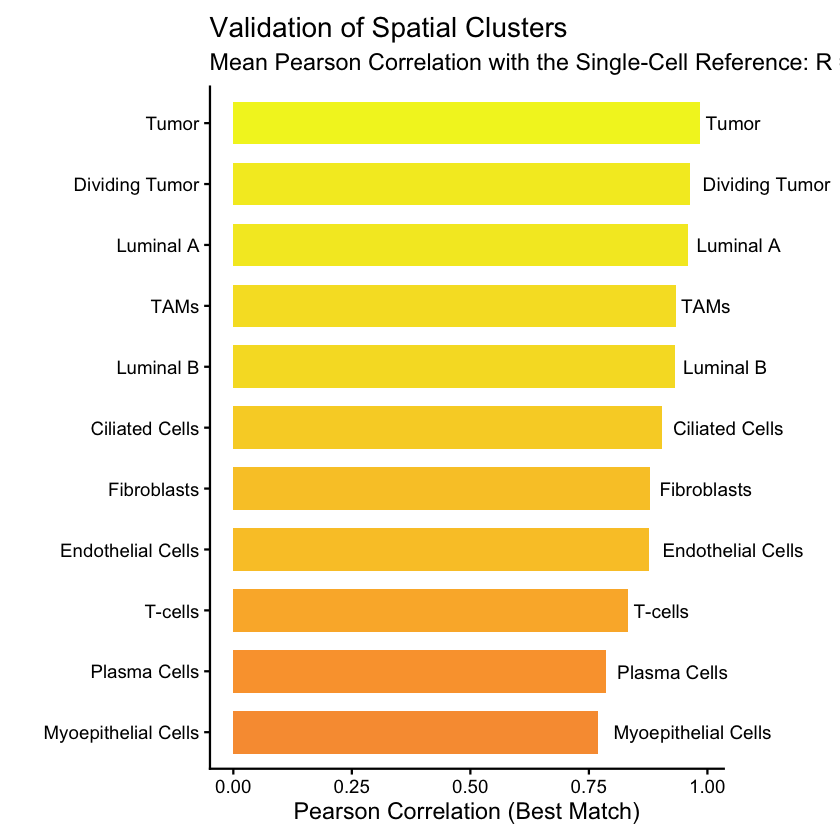

In [12]:
if(file.exists("Validation.csv")) {
  cor_matrix <- read.csv("Validation.csv", row.names = 1, 
                       check.names = FALSE)
} else {
  stop("File not found.")
}

stats_df <- Analyze_Heatmap_Stats(cor_matrix, filename = "Validation_Barplot.png")

print(stats_df)

In [13]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(patchwork)

calc_ccc <- function(x, y) {
  cv <- cov(x, y, use = "complete.obs")
  vx <- var(x, na.rm = TRUE)
  vy <- var(y, na.rm = TRUE)
  mu_x <- mean(x, na.rm = TRUE)
  mu_y <- mean(y, na.rm = TRUE)
  
  ccc <- (2 * cv) / (vx + vy + (mu_x - mu_y)^2)
  return(ccc)
}

PlotBestMatchScatters <- function(spatial_obj, ref_obj, stats_df,
                                  spatial_col = "CellType",
                                  ref_col = "CellType",
                                  n_genes = 3500,
                                  skip_comp_for = c("Ciliated Cells"),
                                  filename = "Scatter_Grid_500dpi.png") {
  
  message(paste0("1. Extraction & Intersection (Target: ", n_genes, " HVGs)..."))
  
  if (length(VariableFeatures(spatial_obj)) < n_genes) {
    spatial_obj <- FindVariableFeatures(spatial_obj, selection.method = "vst", nfeatures = n_genes)
  }
  top_hvg <- toupper(head(VariableFeatures(spatial_obj), n_genes))
  
  sp_assay <- DefaultAssay(spatial_obj)
  spatial_avg <- as.matrix(AverageExpression(spatial_obj, group.by = spatial_col, assays = sp_assay)[[sp_assay]])
  rownames(spatial_avg) <- toupper(rownames(spatial_avg))
  
  ref_assay <- DefaultAssay(ref_obj)
  ref_avg <- as.matrix(AverageExpression(ref_obj, group.by = ref_col, assays = ref_assay)[[ref_assay]])
  rownames(ref_avg) <- toupper(rownames(ref_avg))
  
  common_genes <- intersect(top_hvg, rownames(ref_avg))
  common_genes <- intersect(common_genes, rownames(spatial_avg))
  
  message(paste("   > Scatters will be plotted using", length(common_genes), "common genes."))

  sp_mtx <- log1p(spatial_avg[common_genes, ])
  ref_mtx <- log1p(ref_avg[common_genes, ])
  
  plot_pairs <- stats_df %>% filter(!Visium_Cluster %in% skip_comp_for)
  
  message(paste("2. Generating Scatters for", nrow(plot_pairs), "clusters..."))
  
  plot_list <- list()
  
  for(i in 1:nrow(plot_pairs)) {
    v_clust <- plot_pairs$Visium_Cluster[i]
    r_clust <- plot_pairs$Best_Match_Ref[i]
    
    x_vals <- sp_mtx[, v_clust]
    y_vals <- ref_mtx[, r_clust]
    
    pearson_r <- cor(x_vals, y_vals, method = "pearson")
    ccc_val <- calc_ccc(x_vals, y_vals)
    
    df_plot <- data.frame(Spatial = x_vals, Ref = y_vals)
    
    p <- ggplot(df_plot, aes(x = Spatial, y = Ref)) +
      geom_point(alpha = 0.3, size = 1, color = "#0604D9") + 
      geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "#AD2E00", linewidth = 0.8, alpha = 0.8) +
      labs(
        title = paste(v_clust),
        subtitle = sprintf("Match: %s\nPearson: %.3f | CCC: %.3f", r_clust, pearson_r, ccc_val),
        x = "Average Expression (Visium)",
        y = "Average Expression (scRNA-seq)"
      ) +
      theme_classic(base_size = 12) +
      theme(
        plot.title = element_text(face = "bold", size = 13),
        plot.subtitle = element_text(size = 10, color = "grey30"),
        axis.text = element_text(color = "black")
      )
    
    plot_list[[v_clust]] <- p
  }
  
  message("3. Assembling grid and saving...")
  
  combined_plot <- wrap_plots(plot_list, ncol = 3)
  
  ggsave(filename = filename, 
         plot = combined_plot, 
         width = 12, 
         height = 17, 
         dpi = 500, 
         bg = "white")
  
  message(paste("   > [SAVED] Scatterplots grid saved to:", filename))
  
  return(combined_plot)
}

1. Extraction & Intersection (Target: 3500 HVGs)...

Finding variable features for layer counts

   > Scatters will be plotted using 3500 common genes.

2. Generating Scatters for 11 clusters...

3. Assembling grid and saving...

   > [SAVED] Scatterplots grid saved to: Pearson CCC Scatter Plots.png



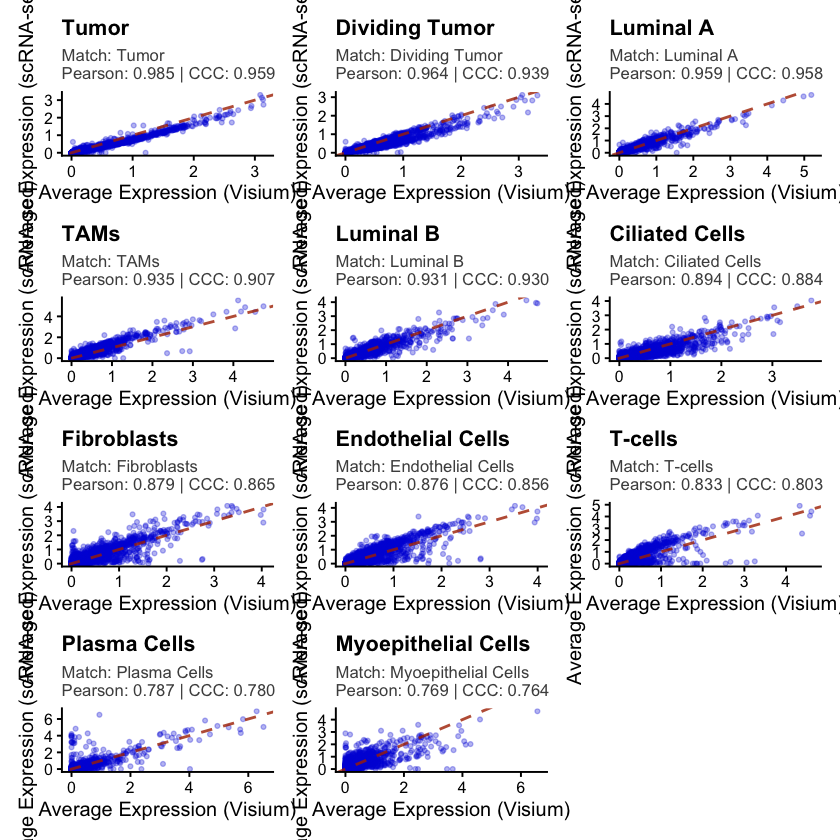

In [14]:
scatter_grid <- PlotBestMatchScatters(
  spatial_obj = seurat_obj, 
  ref_obj = Seurat, 
  stats_df = stats_df,
  spatial_col = "CellType",
  ref_col = "CellType",
  n_genes = 3500,
  skip_comp_for = c(""),
  filename = "Pearson CCC Scatter Plots.png"
)

print(scatter_grid)

In [42]:
library(Seurat)
library(ggplot2)
library(dplyr)

calc_ccc <- function(x, y) {
  cv <- cov(x, y, use = "complete.obs")
  vx <- var(x, na.rm = TRUE)
  vy <- var(y, na.rm = TRUE)
  mu_x <- mean(x, na.rm = TRUE)
  mu_y <- mean(y, na.rm = TRUE)
  
  ccc <- (2 * cv) / (vx + vy + (mu_x - mu_y)^2)
  return(ccc)
}

PlotCCCBoxplot <- function(spatial_obj, ref_obj, stats_df, 
                           spatial_col = "CellType", 
                           ref_col = "CellType", 
                           n_genes = 3500,
                           filename = "CCC_Boxplot_500dpi.png") {
  
  message("1. Extracting data for CCC calculation...")
  
  # Ensure we have the exact same HVGs as the previous steps
  if (length(VariableFeatures(spatial_obj)) < n_genes) {
    spatial_obj <- FindVariableFeatures(spatial_obj, selection.method = "vst", nfeatures = n_genes)
  }
  top_hvg <- toupper(head(VariableFeatures(spatial_obj), n_genes))
  
  # Aggregate Visium Data
  sp_assay <- DefaultAssay(spatial_obj)
  spatial_avg <- as.matrix(AverageExpression(spatial_obj, group.by = spatial_col, assays = sp_assay)[[sp_assay]])
  rownames(spatial_avg) <- toupper(rownames(spatial_avg))
  
  # Aggregate Reference Data
  ref_assay <- DefaultAssay(ref_obj)
  ref_avg <- as.matrix(AverageExpression(ref_obj, group.by = ref_col, assays = ref_assay)[[ref_assay]])
  rownames(ref_avg) <- toupper(rownames(ref_avg))
  
  # Intersect to common space
  common_genes <- intersect(top_hvg, rownames(ref_avg))
  common_genes <- intersect(common_genes, rownames(spatial_avg))
  
  # log1p transformation for accurate linear comparison
  sp_mtx <- log1p(spatial_avg[common_genes, ])
  ref_mtx <- log1p(ref_avg[common_genes, ])
  
  message("2. Calculating CCC for each matched cluster pair...")
  
  # Initialize vectors to store results
  ccc_values <- numeric(nrow(stats_df))
  cluster_names <- character(nrow(stats_df))
  
  for(i in 1:nrow(stats_df)) {
    v_clust <- stats_df$Visium_Cluster[i]
    r_clust <- stats_df$Best_Match_Ref[i]
    
    # Extract vectors and calculate
    x_vals <- sp_mtx[, v_clust]
    y_vals <- ref_mtx[, r_clust]
    
    ccc_values[i] <- calc_ccc(x_vals, y_vals)
    cluster_names[i] <- v_clust
  }
  
  # Build Dataframe for Plotting
  df_ccc <- data.frame(
    Cluster = cluster_names,
    CCC = ccc_values
  )
  
  mean_ccc <- mean(df_ccc$CCC, na.rm = TRUE)
  message(sprintf("   > Average (Mean) CCC: %.4f", mean_ccc))
  
  message("3. Generating Box Plot...")
  
  # Create the Boxplot with jittered points
  p_box <- ggplot(df_ccc, aes(x = "Matched Clusters", y = CCC)) +
    geom_boxplot(width = 0.4, fill = "#35B779", alpha = 0.5, color = "black", outlier.shape = NA) +
    geom_jitter(width = 0.1, size = 3, color = "#440154", alpha = 0.8) +
    geom_hline(yintercept = mean_ccc, linetype = "dashed", color = "#D55E00", linewidth = 1) +
    
    # Add mean annotation text directly to the plot
    annotate("text", x = 1.3, y = mean_ccc, 
             label = sprintf("Mean CCC = %.3f", mean_ccc), 
             color = "#D55E00", size = 5, fontface = "bold") +
    
    # Set Y-axis dynamically based on lowest CCC, capped at 1.0
    scale_y_continuous(limits = c(min(0, min(df_ccc$CCC) - 0.1), 1)) +
    
    labs(
      title = "Concordance Correlation Coefficient",
      subtitle = paste("Distribution across", nrow(df_ccc), "spatial-reference cluster pairs"),
      x = "",
      y = "Lin's CCC"
    ) +
    theme_classic(base_size = 14) +
    theme(
      axis.text.x = element_blank(), # Clean up X axis since there's only one category
      axis.ticks.x = element_blank(),
      plot.title = element_text(face = "bold")
    )
  
  message(paste("4. Saving Box Plot to:", filename))
  
  ggsave(filename = filename, 
         plot = p_box, 
         width = 6, 
         height = 7, 
         dpi = 500, 
         bg = "white")
  
  # Return a list containing both the plot and the raw dataframe
  return(list(plot = p_box, stats = df_ccc, mean = mean_ccc))
}

1. Extracting data for CCC calculation...

Finding variable features for layer counts

2. Calculating CCC for each matched cluster pair...

   > Average (Mean) CCC: 0.8768

3. Generating Box Plot...

4. Saving Box Plot to: CCC_Distribution_Boxplot.png



               Cluster       CCC
1                Tumor 0.9589442
2       Dividing Tumor 0.9386618
3            Luminal A 0.9580276
4                 TAMs 0.9070301
5            Luminal B 0.9300834
6       Ciliated Cells 0.8842227
7          Fibroblasts 0.8647485
8    Endothelial Cells 0.8562469
9              T-cells 0.8032023
10        Plasma Cells 0.7800499
11 Myoepithelial Cells 0.7637305


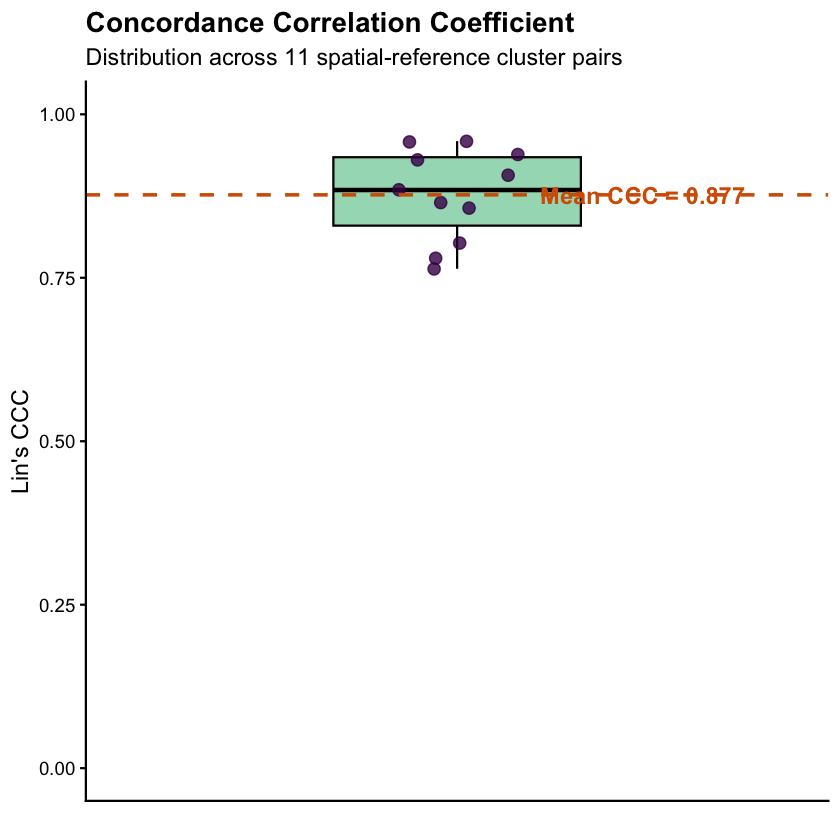

In [43]:
# Run the function
ccc_results <- PlotCCCBoxplot(
  spatial_obj = seurat_obj,
  ref_obj = Seurat,
  stats_df = stats_df,
  spatial_col = "CellType", 
  ref_col = "CellType",
  n_genes = 3500,
  filename = "CCC_Distribution_Boxplot.png"
)

# Display the plot in your R session
print(ccc_results$plot)

# If you want to view the raw CCC dataframe:
print(ccc_results$stats)